# STATE HP sweep on PBMC — MI curves

One line per HP trial, x = quality (log), y = MI per signal.

In [7]:
# Gather results by walking the actual on-disk layout:
#   hp_tunning/hp_trial_XX/<size>/<quality>/
#     ├─ config.json                                               (HP params + metadata; written pre-train)
#     ├─ result.json                                               (post-run; status=ok|error, train_time_s)
#     ├─ checkpoints/**/version_*/metrics.csv                      (Lightning train/val loss curves)
#     └─ MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt
#
# The hp_trial_XX.yaml index files are only written once the whole sweep finishes,
# so we walk hp_trial_* directly and read config.json for HP params.
# Per-step training and validation loss curves come from Lightning's CSVLogger.
# The resulting DataFrame holds scalars; the raw curves live in the CURVES dict.
import json
import re
from pathlib import Path

import pandas as pd

OUTPUT_DIR = Path('/home/igor/noise_scaling/data/other/hp_tunning')
MI_SEED = 42  # first seed emitted by latentmi

def _num(s: str):
    try: return int(s)
    except ValueError:
        try: return float(s)
        except ValueError: return s

def _read_metrics(leaf: Path):
    """Return (train_df, val_df) from Lightning's metrics.csv, or (None, None).

    train_df: columns [step, train_loss]; val_df: columns [step, val_loss].
    Rows without the corresponding loss value are dropped and each is sorted by step.
    """
    matches = sorted(leaf.glob('checkpoints/**/version_*/metrics.csv'))
    if not matches:
        return None, None
    m = pd.read_csv(matches[0])
    tcol, vcol = 'trainer/train_loss', 'validation/val_loss'
    train_df = (m.dropna(subset=[tcol])[['step', tcol]].rename(columns={tcol: 'train_loss'})
                 .sort_values('step').reset_index(drop=True)) if tcol in m.columns else None
    val_df   = (m.dropna(subset=[vcol])[['step', vcol]].rename(columns={vcol: 'val_loss'})
                 .sort_values('step').reset_index(drop=True)) if vcol in m.columns else None
    return train_df, val_df

rows = []
CURVES: dict = {}  # (trial_id, size, quality) -> {'train': DataFrame, 'val': DataFrame}

for trial_dir in sorted(OUTPUT_DIR.glob('hp_trial_*')):
    if not trial_dir.is_dir():
        continue
    m = re.match(r'hp_trial_(\d+)$', trial_dir.name)
    if not m:
        continue
    trial_id = int(m.group(1))

    for size_dir in sorted(p for p in trial_dir.iterdir() if p.is_dir()):
        size_val = _num(size_dir.name)
        if not isinstance(size_val, (int, float)):
            continue
        for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
            quality_val = _num(q_dir.name)
            if not isinstance(quality_val, (int, float)):
                continue

            cfg_path = q_dir / 'config.json'
            cfg = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
            row = {
                'trial_id': trial_id,
                'trial_name': cfg.get('trial_name', f'hp_trial_{trial_id:02d}'),
                'size': int(size_val),
                'quality': float(quality_val),
                **(cfg.get('swept_params') or {}),
            }

            res_path = q_dir / 'result.json'
            if res_path.exists():
                try:
                    res = json.loads(res_path.read_text())
                    row['status'] = res.get('status', 'unknown')
                    row['train_time_s'] = res.get('train_time_s')
                except json.JSONDecodeError:
                    row['status'] = 'corrupt'
            else:
                row['status'] = 'pending'

            # Training / validation loss curves from Lightning's metrics.csv.
            # Final values go into df; full curves live in CURVES for plotting.
            train_df, val_df = _read_metrics(q_dir)
            if train_df is not None and len(train_df):
                row['train_loss_final'] = float(train_df['train_loss'].iloc[-1])
                row['n_train_steps'] = int(train_df['step'].iloc[-1])
            if val_df is not None and len(val_df):
                row['val_loss_final'] = float(val_df['val_loss'].iloc[-1])
            CURVES[(trial_id, int(size_val), float(quality_val))] = {
                'train': train_df, 'val': val_df,
            }

            mi_root = q_dir / 'MI' / str(MI_SEED)
            if mi_root.is_dir():
                for sig_dir in filter(Path.is_dir, mi_root.iterdir()):
                    # Y_<signal>_<quality-as-text>  ->  strip the trailing quality suffix
                    sm = re.match(r'Y_(.+)_[0-9][0-9_.]*$', sig_dir.name)
                    signal = sm.group(1) if sm else sig_dir.name
                    f = sig_dir / 'lmi_mutual_information.txt'
                    if f.exists():
                        try: row[f'mi_{signal}'] = float(f.read_text().strip())
                        except ValueError: pass
            rows.append(row)

df = pd.DataFrame(rows)
if len(df):
    df = df.sort_values(['trial_id', 'size', 'quality']).reset_index(drop=True)
mi_cols_found = sorted(c for c in df.columns if c.startswith('mi_'))
n_trials = df['trial_id'].nunique() if len(df) else 0
n_ok = int((df['status'] == 'ok').sum()) if 'status' in df.columns else 0
n_curves = sum(1 for v in CURVES.values() if v['train'] is not None and len(v['train']))
print(f'{len(df)} rows across {n_trials} trials  ok={n_ok}  curves={n_curves}  mi_cols={mi_cols_found}')
df

160 rows across 16 trials  ok=159  curves=160  mi_cols=['mi_celltype.l3', 'mi_protein_counts']


,trial_id,trial_name,size,quality,dropout,batch_size,max_lr,weight_decay,status,train_time_s,train_loss_final,n_train_steps,val_loss_final,mi_celltype.l3,mi_protein_counts
0,0,hp_trial_00_100000_0.0012346,100000,0.001235,0.3,64,0.0001,0.1000,ok,5334.567772,8.982543,3119,5.985038,0.22919,0.31068
1,0,hp_trial_00_100000_0.0025982,100000,0.002598,0.3,64,0.0001,0.1000,ok,4101.764017,12.469963,3135,10.172843,0.69752,0.65150
2,0,hp_trial_00_100000_0.0054682,100000,0.005468,0.3,64,0.0001,0.1000,ok,4637.131062,13.083869,3135,11.754370,1.04089,1.08539
3,0,hp_trial_00_100000_0.0115083,100000,0.011508,0.3,64,0.0001,0.1000,ok,4166.887816,14.059572,3135,13.938963,1.25358,1.23527
4,0,hp_trial_00_100000_0.02422,100000,0.024220,0.3,64,0.0001,0.1000,ok,4173.694333,14.885730,3135,15.475825,1.60997,1.76011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,15,hp_trial_15_100000_0.050973,100000,0.050973,0.0,32,0.0010,0.0001,ok,4982.728262,14.729032,6255,13.477683,0.03100,0.05728
156,15,hp_trial_15_100000_0.1072766,100000,0.107277,0.0,32,0.0010,0.0001,ok,5606.108599,11.763534,6255,11.476081,0.31496,0.39818
157,15,hp_trial_15_100000_0.225772,100000,0.225772,0.0,32,0.0010,0.0001,ok,4961.960842,11.733836,6255,12.045682,0.60090,0.62508
158,15,hp_trial_15_100000_0.4751547,100000,0.475155,0.0,32,0.0010,0.0001,ok,5099.630996,13.107945,6255,13.117988,0.02440,0.04360


In [8]:
# Completion matrix: rows = HP trials (16), cols = qualities (10).
# Cell = status from result.json ('ok' / 'error' / 'pending' / 'corrupt' / missing).
# Bottom rows summarise per-quality totals; right-most column summarises per-trial totals.
EXPECTED_TRIALS = 16
EXPECTED_QUALITIES = 10

if not len(df):
    print('df is empty — nothing to tally.')
else:
    status_mat = df.pivot_table(index='trial_id', columns='quality',
                                values='status', aggfunc='first').sort_index()
    # Fill any (trial, quality) combinations we never walked (directory absent) as 'missing'.
    status_mat = status_mat.fillna('missing')

    def _ok(v):  return (v == 'ok').sum()
    def _bad(v): return ((v != 'ok') & (v.notna())).sum()

    trial_done    = status_mat.apply(lambda r: (r == 'ok').sum(), axis=1)
    trial_missing = status_mat.shape[1] - trial_done
    quality_done    = status_mat.apply(lambda c: (c == 'ok').sum(), axis=0)
    quality_missing = status_mat.shape[0] - quality_done

    display_mat = status_mat.copy()
    display_mat['done']    = trial_done
    display_mat['missing'] = trial_missing

    summary = pd.DataFrame(
        [list(quality_done) + [quality_done.sum(), quality_missing.sum()],
         list(quality_missing) + ['', '']],
        index=['done', 'missing'], columns=display_mat.columns,
    )
    full = pd.concat([display_mat, summary])

    total_cells   = status_mat.size
    total_done    = int((status_mat == 'ok').sum().sum())
    total_missing = total_cells - total_done
    print(f'trials seen: {status_mat.shape[0]} / expected {EXPECTED_TRIALS}   '
          f'qualities seen: {status_mat.shape[1]} / expected {EXPECTED_QUALITIES}')
    print(f'runs done (status=ok): {total_done} / {total_cells}   missing: {total_missing}')
    full


trials seen: 16 / expected 16   qualities seen: 10 / expected 10
runs done (status=ok): 159 / 160   missing: 1


In [9]:
# Original-work baselines: load MI for the per-algorithm runs that live alongside the HP sweep.
# Layout:  data/PBMC/<size>/<quality>/results/<algo>/model/MI/<seed>/Y_<signal>_<quality>[_<algo_tag>]/lmi_mutual_information.txt
# Geneformer tags its signal dirs with a `_geneformer` suffix, which the previous regex rejected.
import re
from pathlib import Path

import pandas as pd

ORIG_ROOT = Path('/home/igor/noise_scaling/data/PBMC')
ORIG_SIZE = 100000
ORIG_SEED = 42
ORIG_SIGNAL = 'protein_counts'  # match mi_col in the HP-sweep plot above

# Y_<signal>_<quality>[_<algo_tag>]  — allow an optional trailing alpha suffix (e.g. "_geneformer").
SIG_RE = re.compile(r'Y_(.+?)_[0-9][0-9_.]*(?:_[A-Za-z]+)?$')

orig_rows = []
size_dir = ORIG_ROOT / str(ORIG_SIZE)
for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
    try:
        quality = float(q_dir.name)
    except ValueError:
        continue
    results_dir = q_dir / 'results'
    if not results_dir.is_dir():
        continue
    for algo_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        algo = algo_dir.name
        if algo == 'TunableState':
            continue  # that's the HP sweep, already plotted
        mi_root = algo_dir / 'model' / 'MI' / str(ORIG_SEED)
        if not mi_root.is_dir():
            continue
        for sig_dir in mi_root.iterdir():
            if not sig_dir.is_dir():
                continue
            m = SIG_RE.match(sig_dir.name)
            signal = m.group(1) if m else sig_dir.name
            if signal != ORIG_SIGNAL:
                continue
            f = sig_dir / 'lmi_mutual_information.txt'
            if not f.exists():
                continue
            try:
                mi_val = float(f.read_text().strip())
            except ValueError:
                continue
            orig_rows.append({'algo': algo, 'quality': quality, 'mi': mi_val})

orig_df = pd.DataFrame(orig_rows).sort_values(['algo', 'quality']).reset_index(drop=True)
print(f'{len(orig_df)} original-work points across {orig_df["algo"].nunique()} algos: {sorted(orig_df["algo"].unique())}')
orig_df

50 original-work points across 5 algos: ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']


,algo,quality,mi
0,Geneformer,0.001235,0.74752
1,Geneformer,0.002598,1.30775
2,Geneformer,0.005468,1.70259
3,Geneformer,0.011508,2.29315
4,Geneformer,0.024220,2.77658
5,Geneformer,0.050973,3.09976
6,Geneformer,0.107277,3.45581
7,Geneformer,0.225772,3.50053
8,Geneformer,0.475155,3.66358
9,Geneformer,1.000000,3.43401


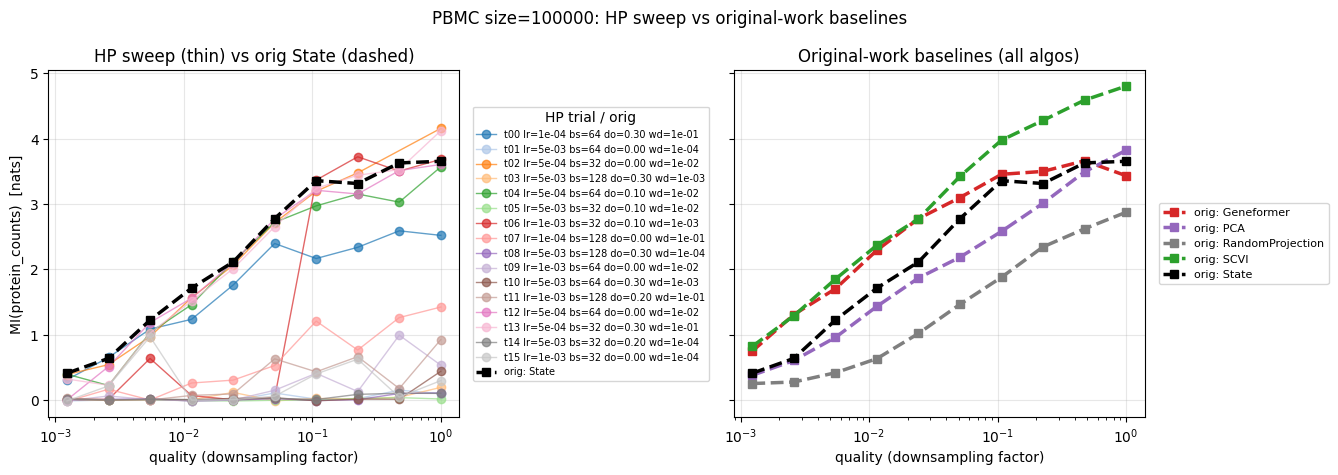

In [10]:
# Overlay, split into two panels (shared y-axis):
#   Left:  HP-sweep MI curves (one line per HP trial) + original-work State baseline.
#   Right: all original-work baselines (State + every other algorithm, incl. Geneformer).
import matplotlib.pyplot as plt

mi_col = 'mi_protein_counts'
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)

algo_colors = {
    'State':            'k',
    'Geneformer':       'tab:red',
    'SCVI':             'tab:green',
    'PCA':              'tab:purple',
    'RandomProjection': 'tab:gray',
}

# --- Left: HP sweep (thin) + original State (dashed) ---
trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')
for i, tid in enumerate(trial_ids):
    sub = df[(df['trial_id'] == tid) & df[mi_col].notna()].sort_values('quality')
    if sub.empty:
        continue
    cfg = sub.iloc[0]
    label = (f"t{int(tid):02d} "
             f"lr={cfg['max_lr']:.0e} bs={int(cfg['batch_size'])} "
             f"do={cfg['dropout']:.2f} wd={cfg['weight_decay']:.0e}")
    ax_l.plot(sub['quality'].values, sub[mi_col].values,
              marker='o', linewidth=1.0, alpha=0.7,
              color=cmap(i % cmap.N), label=label)

state_sub = orig_df[orig_df['algo'] == 'State'].sort_values('quality')
if not state_sub.empty:
    ax_l.plot(state_sub['quality'].values, state_sub['mi'].values,
              marker='s', linewidth=2.5, linestyle='--',
              color=algo_colors['State'], label='orig: State', zorder=5)

ax_l.set_xscale('log')
ax_l.set_xlabel('quality (downsampling factor)')
ax_l.set_ylabel(f'MI({ORIG_SIGNAL})  [nats]')
ax_l.set_title('HP sweep (thin) vs orig State (dashed)')
ax_l.grid(alpha=0.3)
ax_l.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1,
            title='HP trial / orig')

# --- Right: all original-work baselines (State + every other algo) ---
for algo, sub in orig_df.groupby('algo'):
    sub = sub.sort_values('quality')
    ax_r.plot(sub['quality'].values, sub['mi'].values,
              marker='s', linewidth=2.5, linestyle='--',
              color=algo_colors.get(algo, None),
              label=f'orig: {algo}', zorder=5)

ax_r.set_xscale('log')
ax_r.set_xlabel('quality (downsampling factor)')
ax_r.set_title('Original-work baselines (all algos)')
ax_r.grid(alpha=0.3)
ax_r.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)

fig.suptitle(f'PBMC size={ORIG_SIZE}: HP sweep vs original-work baselines')
plt.tight_layout()
plt.show()

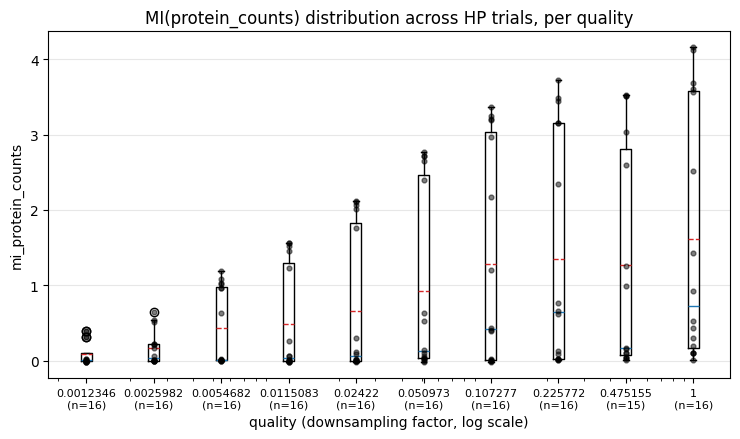

In [11]:
# Box plot: distribution of mi_protein_counts across HP trials, one box per quality.
# x-axis is true log scale (positions = quality, ax.set_xscale('log')).
import matplotlib.pyplot as plt
import numpy as np

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    sub = df[df[mi_col].notna()]
    qualities = sorted(sub['quality'].unique())
    data = [sub.loc[sub['quality'] == q, mi_col].values for q in qualities]
    n_per = [len(d) for d in data]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    positions = np.array(qualities, dtype=float)
    # On a log axis, a constant linear `width` would look microscopic at small x
    # and huge at large x. Pick a constant log-space half-width (≈12%) and emit
    # asymmetric widths in linear units that map to it.
    w = 0.12
    widths = positions * (np.exp(w) - np.exp(-w)) / 2
    ax.boxplot(data, positions=positions, widths=widths,
               showmeans=True, meanline=True,
               medianprops=dict(color='C0'),
               meanprops=dict(color='C3', linestyle='--'))
    for pos, d in zip(positions, data):
        ax.scatter(np.full_like(d, pos, dtype=float), d,
                   s=12, alpha=0.5, color='k', zorder=3)

    ax.set_xscale('log')
    ax.set_xticks(positions)
    ax.set_xticklabels([f'{q:g}\n(n={n})' for q, n in zip(qualities, n_per)],
                       fontsize=8)
    ax.set_xlabel('quality (downsampling factor, log scale)')
    ax.set_ylabel('mi_protein_counts')
    ax.set_title('MI(protein_counts) distribution across HP trials, per quality')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

orig State curves loaded: train=10/10 val=10/10


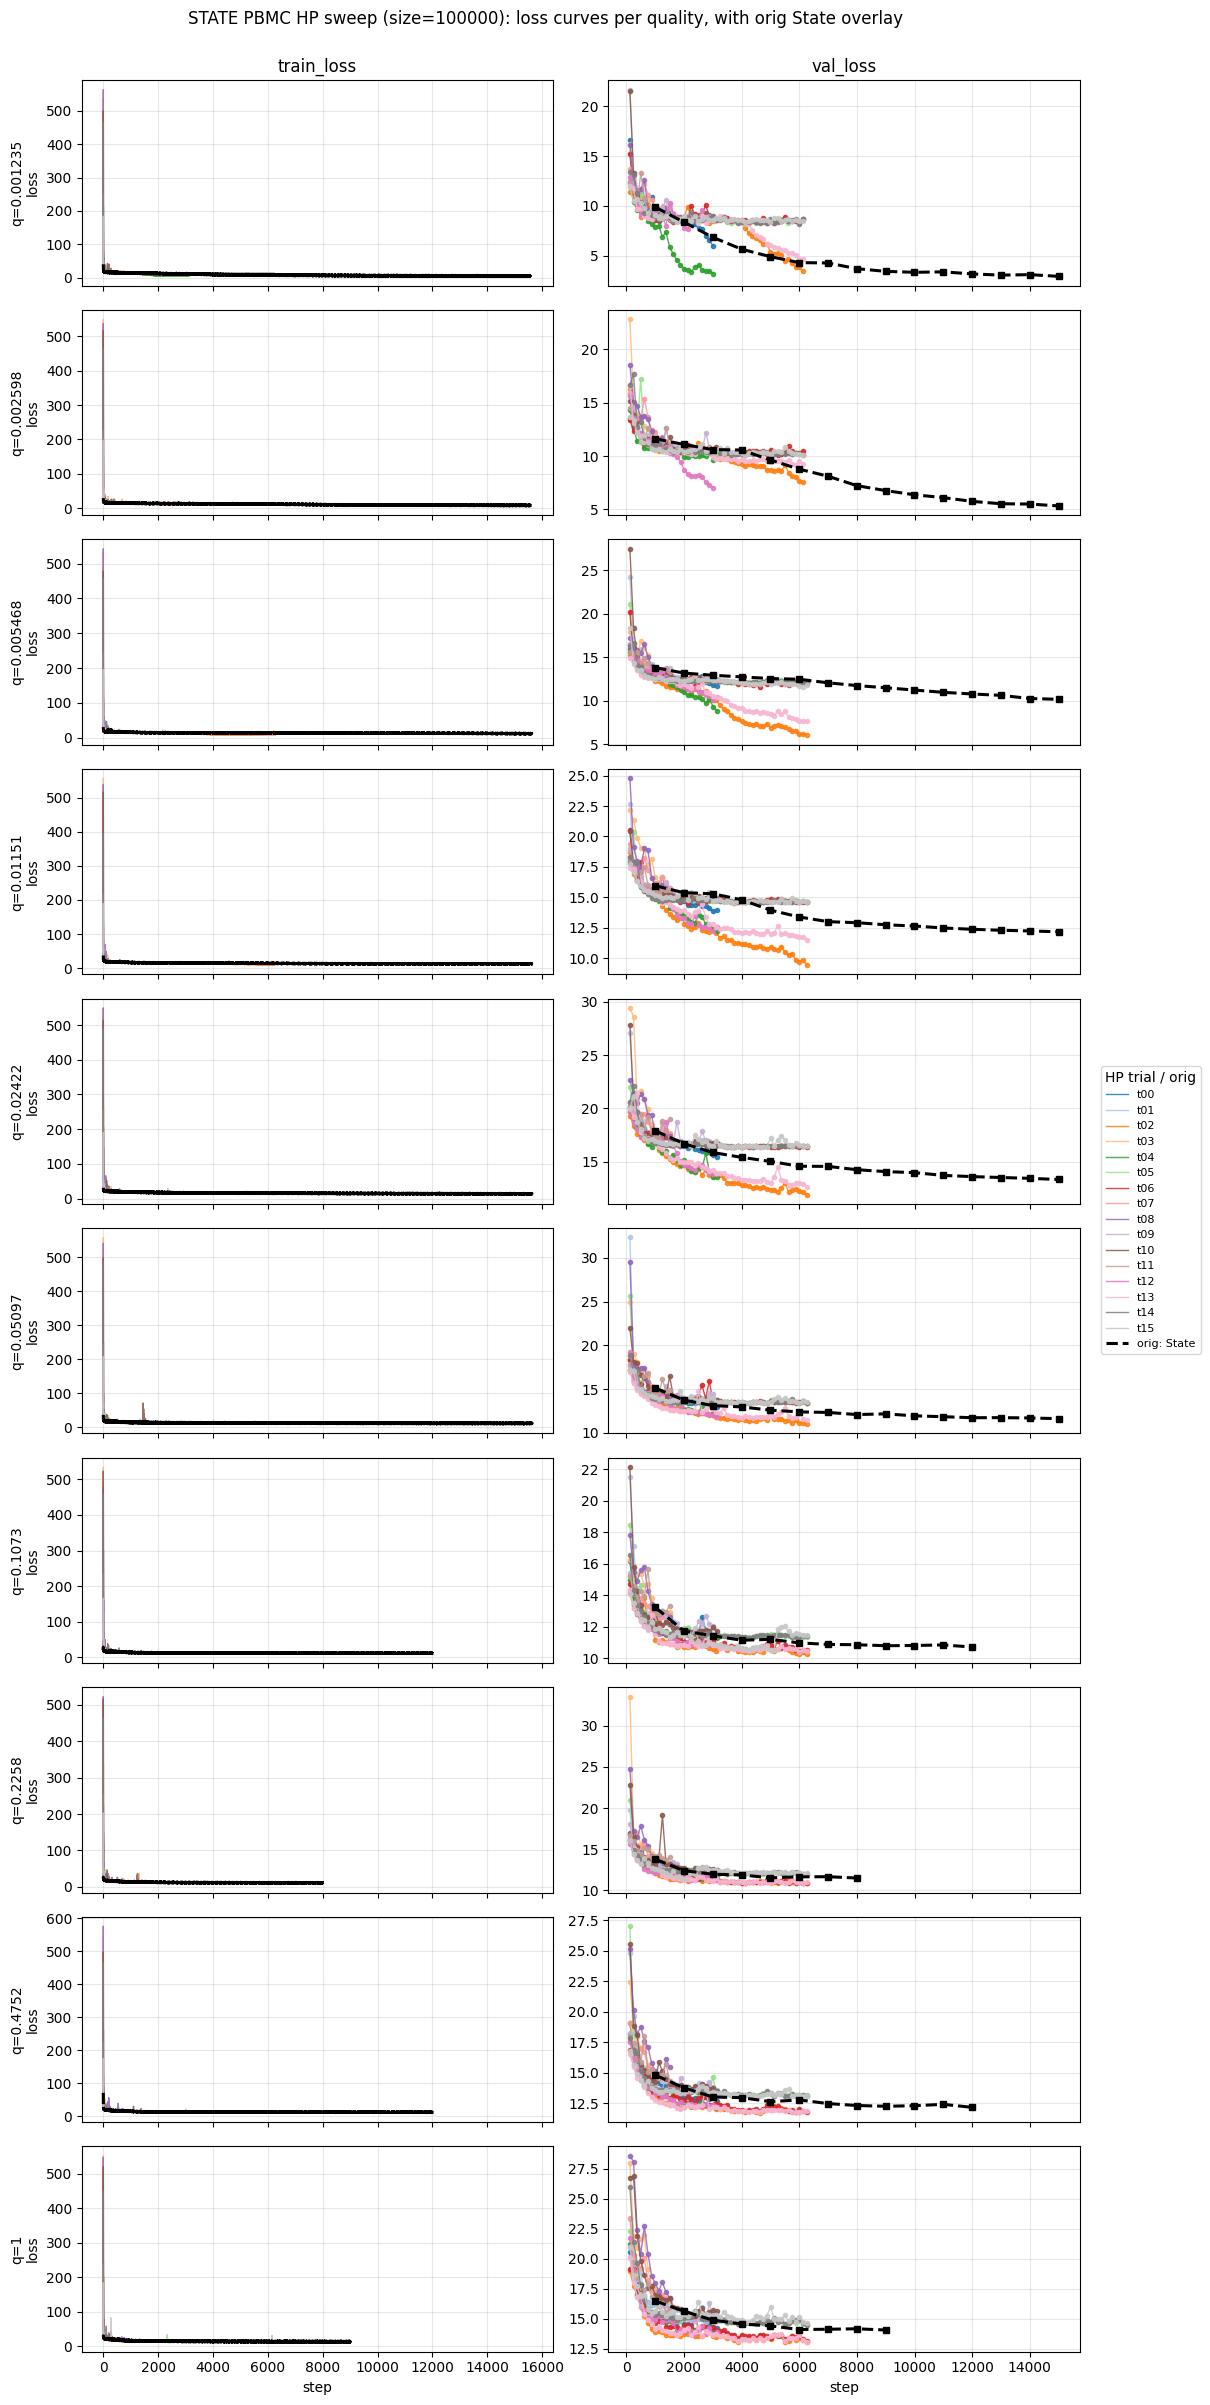

In [12]:
# Train / validation loss curves on linear axes: 2 columns (train, val), 1 row per quality.
# Each subplot overlays one line per HP trial (using the curves stashed in CURVES) plus
# the original-work State training curve at the same (size, quality) as a bold black
# dashed line — pulled from data/PBMC/<size>/<quality>/results/State/model/loss/metrics.csv.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ORIG_STATE_ROOT = Path('/home/igor/noise_scaling/data/PBMC')

def _orig_state_curves(size: int, quality) -> tuple[pd.DataFrame | None, pd.DataFrame | None]:
    """Load (train_df, val_df) from the orig-work State run at (size, quality).

    Mirrors `_read_metrics` above, but walks the data/PBMC/... tree where
    scaling_laws/algo/state.py copies metrics.csv into results/State/model/loss/.
    Falls back to the raw Lightning checkpoint dir if the copy is missing.
    """
    base = ORIG_STATE_ROOT / str(size) / str(quality) / 'results' / 'State' / 'model'
    candidates = [base / 'loss' / 'metrics.csv'] + sorted(
        base.glob('checkpoints/**/version_*/metrics.csv')
    )
    for m in candidates:
        if not m.exists() or m.stat().st_size == 0:
            continue
        try:
            df_m = pd.read_csv(m, on_bad_lines='skip')
        except Exception:
            continue
        tcol, vcol = 'trainer/train_loss', 'validation/val_loss'
        tr = (df_m.dropna(subset=[tcol])[['step', tcol]].rename(columns={tcol: 'train_loss'})
                .sort_values('step').reset_index(drop=True)) if tcol in df_m.columns else None
        va = (df_m.dropna(subset=[vcol])[['step', vcol]].rename(columns={vcol: 'val_loss'})
                .sort_values('step').reset_index(drop=True)) if vcol in df_m.columns else None
        if (tr is not None and len(tr)) or (va is not None and len(va)):
            return tr, va
    return None, None

qualities = sorted(df['quality'].unique())
trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')
trial_color = {tid: cmap(i % cmap.N) for i, tid in enumerate(trial_ids)}

# Same size used by the HP sweep (single size in this notebook).
sizes = sorted({k[1] for k in CURVES}) or [100000]
orig_size = sizes[0]

# Pre-load orig State curves once per quality.
ORIG_CURVES = {q: _orig_state_curves(orig_size, q) for q in qualities}
n_orig_tr = sum(1 for tr, _ in ORIG_CURVES.values() if tr is not None and len(tr))
n_orig_va = sum(1 for _, va in ORIG_CURVES.values() if va is not None and len(va))
print(f'orig State curves loaded: train={n_orig_tr}/{len(qualities)} val={n_orig_va}/{len(qualities)}')

n_rows = len(qualities)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.4 * n_rows),
                         sharex='col', squeeze=False)

for r, q in enumerate(qualities):
    ax_tr, ax_va = axes[r, 0], axes[r, 1]
    for tid in trial_ids:
        # CURVES is keyed (trial_id, size, quality); pick whichever size(s) exist for this trial+quality.
        keys = [k for k in CURVES if k[0] == tid and np.isclose(k[2], q)]
        for key in keys:
            curves = CURVES[key]
            tr, va = curves['train'], curves['val']
            color = trial_color[tid]
            if tr is not None and len(tr):
                ax_tr.plot(tr['step'].values, tr['train_loss'].values,
                           color=color, linewidth=1.0, alpha=0.85,
                           label=f't{tid:02d}' if r == 0 else None)
            if va is not None and len(va):
                ax_va.plot(va['step'].values, va['val_loss'].values,
                           color=color, linewidth=1.0, alpha=0.85, marker='o', markersize=3,
                           label=f't{tid:02d}' if r == 0 else None)

    # Overlay orig-work State curve (bold black dashed), same style as the MI baseline plot.
    otr, ova = ORIG_CURVES.get(q, (None, None))
    if otr is not None and len(otr):
        ax_tr.plot(otr['step'].values, otr['train_loss'].values,
                   color='k', linewidth=2.2, linestyle='--', zorder=5,
                   label='orig: State' if r == 0 else None)
    if ova is not None and len(ova):
        ax_va.plot(ova['step'].values, ova['val_loss'].values,
                   color='k', linewidth=2.2, linestyle='--', marker='s', markersize=4,
                   zorder=5, label='orig: State' if r == 0 else None)

    ax_tr.set_ylabel(f'q={q:.4g}\nloss')
    ax_tr.grid(alpha=0.3)
    ax_va.grid(alpha=0.3)

axes[0, 0].set_title('train_loss')
axes[0, 1].set_title('val_loss')
axes[-1, 0].set_xlabel('step')
axes[-1, 1].set_xlabel('step')

# Single legend for the whole figure (HP trials + orig State).
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='HP trial / orig')
fig.suptitle(f'STATE PBMC HP sweep (size={orig_size}): loss curves per quality, with orig State overlay', y=1.0)
plt.tight_layout()
plt.show()
